# LightGBM LTV-предсказание (v4 Исправленная)

Третья базовая модель. Использует leaf-wise сплит для ортогональности к CatBoost.

Исправления:
- **Критический баг:** В предыдущей версии загружался файл `feature_importance_v2.json`, из-за чего модель не видела мощных фичей за 270 и 365 дней.
- **Теперь:** Загружается `feature_importance_v4.json`. 
- **Параметры:** Single-Fold (`N_FOLDS = 2`), обучение на GPU.

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import json
import lightgbm as lgb
from pathlib import Path
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import optuna

FEATURES_DIR = Path("../data/processed/features_v4")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

N_FOLDS = 2
N_OPTUNA_TRIALS = 20

def rmsle_score(y_true, y_pred):
    y_pred_clipped = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred_clipped)))

def gini_normalized(y_true, y_pred):
    def _gini(actual, predicted):
        n = len(actual)
        indices = np.argsort(-predicted)
        sorted_actual = actual[indices]
        cumulative = np.cumsum(sorted_actual)
        gini_sum = cumulative.sum() / sorted_actual.sum() - (n + 1) / 2
        return gini_sum / n
    return _gini(y_true, y_pred) / _gini(y_true, y_true)

def rmspe_total_gmv(y_true, y_pred):
    total_true = y_true.sum()
    total_pred = max(y_pred.sum(), 1e-8)
    return abs(total_true - total_pred) / total_true * 100

def load_fold(fold_path: Path) -> pd.DataFrame:
    df = pl.read_parquet(fold_path / "batch_*.parquet")
    return df.to_pandas()

## Загрузка данных и Feature Selection

In [ ]:
TOP_N_FEATURES = 150

imp_path = Path("../data/processed/feature_importance_v4.json")
if imp_path.exists():
    with open(imp_path) as f:
        imp_data = json.load(f)
    ranked_features = [item["name"] for item in imp_data["features_ranked"]]
else:
    imp_path = Path("../data/processed/feature_importance_v3.json")
    if imp_path.exists():
        with open(imp_path) as f:
            imp_data = json.load(f)
        ranked_features = [item["name"] for item in imp_data["features_ranked"]]
    else:
        ranked_features = None

print("Загрузка данных...")
test_df = load_fold(FEATURES_DIR / "fold_test")

drop_cols = ["user_id", "anchor_date", "target"]
all_features = [c for c in test_df.columns if c not in drop_cols]

if ranked_features:
    features = [f for f in ranked_features if f in all_features][:TOP_N_FEATURES]
else:
    features = all_features

print(f"Фичей: {len(features)} (из {len(all_features)})")

all_folds = []
for fold_idx in range(N_FOLDS):
    fold_df = load_fold(FEATURES_DIR / f"fold_{fold_idx:02d}")
    all_folds.append(fold_df)
    print(f"  Фолд {fold_idx}: {len(fold_df):,} записей")

test_predictions = np.zeros(len(test_df))
trained_models = []

Загрузка данных...
Фичей: 150 (из 392)
  Фолд 0: 250,000 записей
  Фолд 1: 250,000 записей


## Optuna тюнинг LightGBM

In [ ]:
print(f"Запуск Optuna LightGBM ({N_OPTUNA_TRIALS} триалов)...\n")

def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'seed': 42,
        'device': 'gpu',
        'gpu_use_dp': False,
        'n_estimators': trial.suggest_int('n_estimators', 1000, 5000, step=500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 200),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    
    scores = []
    for val_idx in range(1, N_FOLDS):
        train_df = all_folds[val_idx - 1]
        val_df = all_folds[val_idx]
        
        y_train_log = np.log1p(np.clip(train_df["target"], 0, None))
        y_val = val_df["target"].values
        y_val_log = np.log1p(np.clip(y_val, 0, None))
        
        train_set = lgb.Dataset(train_df[features], y_train_log)
        val_set = lgb.Dataset(val_df[features], y_val_log, reference=train_set)
        
        callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=0)]
        model = lgb.train(params, train_set, valid_sets=[val_set], callbacks=callbacks)
        
        val_pred = np.expm1(np.clip(model.predict(val_df[features]), 0, None))
        scores.append(rmsle_score(y_val, val_pred))
        
        trial.report(np.mean(scores), val_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return np.mean(scores)

def print_callback(study, trial):
    status = "PRUNED" if trial.state == optuna.trial.TrialState.PRUNED else f"RMSLE={trial.value:.5f}"
    print(f"  Trial {trial.number+1:2d}/{N_OPTUNA_TRIALS}: {status} "
          f"(лучший: {study.best_value:.5f}, trial #{study.best_trial.number+1})")

study = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, callbacks=[print_callback])

print(f"\n--- Итоги ---")
print(f"Лучший RMSLE: {study.best_value:.5f}")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-08-17 05:37:36,058] A new study created in memory with name: no-name-3682a73e-9bc6-4402-939e-b89c36fbe3b7


Запуск Optuna LightGBM (20 триалов)...

  Trial  1/20: RMSLE=1.67167 (лучший: 1.67167, trial #1)
  Trial  2/20: RMSLE=1.67740 (лучший: 1.67167, trial #1)
  Trial  3/20: RMSLE=1.67346 (лучший: 1.67167, trial #1)
  Trial  4/20: RMSLE=1.67367 (лучший: 1.67167, trial #1)
  Trial  5/20: RMSLE=1.67229 (лучший: 1.67167, trial #1)
  Trial  6/20: PRUNED (лучший: 1.67167, trial #1)
  Trial  7/20: RMSLE=1.67142 (лучший: 1.67142, trial #7)
  Trial  8/20: PRUNED (лучший: 1.67142, trial #7)
  Trial  9/20: RMSLE=1.66456 (лучший: 1.66456, trial #9)
  Trial 10/20: PRUNED (лучший: 1.66456, trial #9)
  Trial 11/20: RMSLE=1.67105 (лучший: 1.66456, trial #9)
  Trial 12/20: RMSLE=1.67019 (лучший: 1.66456, trial #9)
  Trial 13/20: RMSLE=1.66741 (лучший: 1.66456, trial #9)
  Trial 14/20: RMSLE=1.66638 (лучший: 1.66456, trial #9)
  Trial 15/20: RMSLE=1.66569 (лучший: 1.66456, trial #9)
  Trial 16/20: RMSLE=1.66816 (лучший: 1.66456, trial #9)
  Trial 17/20: RMSLE=1.66845 (лучший: 1.66456, trial #9)
  Trial 18/2

## Финальное обучение

In [ ]:
best_params = study.best_params
best_params.update({
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'seed': 42,
    'device': 'gpu',
    'gpu_use_dp': False,
})

fold_scores = []
fold_gini = []
fold_rmspe = []

for val_idx in range(1, N_FOLDS):
    train_df = all_folds[val_idx - 1]
    val_df = all_folds[val_idx]
    
    train_str = "+".join([str(i) for i in range(val_idx)])
    print(f"--- Train: [{train_str}] ({len(train_df):,}) | Val: fold {val_idx} ({len(val_df):,}) ---")
    
    y_train_log = np.log1p(np.clip(train_df["target"], 0, None))
    y_val = val_df["target"].values
    y_val_log = np.log1p(np.clip(y_val, 0, None))
    
    train_set = lgb.Dataset(train_df[features], y_train_log)
    val_set = lgb.Dataset(val_df[features], y_val_log, reference=train_set)
    
    callbacks = [lgb.early_stopping(150, verbose=True), lgb.log_evaluation(period=250)]
    model = lgb.train(best_params, train_set, valid_sets=[val_set], callbacks=callbacks)
    trained_models.append(model)
    
    val_pred = np.expm1(np.clip(model.predict(val_df[features]), 0, None))
    
    score = rmsle_score(y_val, val_pred)
    gini = gini_normalized(y_val, val_pred)
    rmspe = rmspe_total_gmv(y_val, val_pred)
    fold_scores.append(score)
    fold_gini.append(gini)
    fold_rmspe.append(rmspe)
    
    print(f"RMSLE: {score:.5f} | Gini: {gini:.4f} | RMSPE: {rmspe:.2f}%\n")
    
    test_pred_log = model.predict(test_df[features])
    test_predictions += np.expm1(np.clip(test_pred_log, 0, None)) / (N_FOLDS - 1)
    
    model.save_model(str(MODELS_DIR / f"lgbm_v4_fold_{val_idx}.txt"))

print("="*60)
print(f"LightGBM средний RMSLE: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
print(f"Средний Gini: {np.mean(fold_gini):.4f}")
print(f"Средний RMSPE: {np.mean(fold_rmspe):.2f}%")

submit_df = test_df[["user_id"]].copy()
submit_df["predict"] = np.clip(test_predictions, 0, None)
submit_path = Path("../data/processed/lgbm_v4_submission.csv")
submit_df.to_csv(submit_path, index=False)
print(f"\nСохранено: {submit_path}")
print(f"mean={submit_df['predict'].mean():.2f} | median={submit_df['predict'].median():.2f}")

--- Train: [0] (250,000) | Val: fold 1 (250,000) ---
Training until validation scores don't improve for 150 rounds
[250]	valid_0's rmse: 1.67827
[500]	valid_0's rmse: 1.6759
[750]	valid_0's rmse: 1.67424
[1000]	valid_0's rmse: 1.67284
[1250]	valid_0's rmse: 1.67179
[1500]	valid_0's rmse: 1.67092
[1750]	valid_0's rmse: 1.67014
[2000]	valid_0's rmse: 1.66952
[2250]	valid_0's rmse: 1.66884
[2500]	valid_0's rmse: 1.66841
[2750]	valid_0's rmse: 1.6679
[3000]	valid_0's rmse: 1.6675
[3250]	valid_0's rmse: 1.66699
[3500]	valid_0's rmse: 1.66646
[3750]	valid_0's rmse: 1.66617
[4000]	valid_0's rmse: 1.66575
[4250]	valid_0's rmse: 1.66541
[4500]	valid_0's rmse: 1.66514
[4750]	valid_0's rmse: 1.66488
[5000]	valid_0's rmse: 1.66448
Did not meet early stopping. Best iteration is:
[4989]	valid_0's rmse: 1.66448
RMSLE: 1.66445 | Gini: 0.7384 | RMSPE: 56.94%

LightGBM средний RMSLE: 1.66445 ± 0.00000
Средний Gini: 0.7384
Средний RMSPE: 56.94%

Сохранено: ..\data\processed\lgbm_v4_submission.csv
mean=35

## Feature Importance

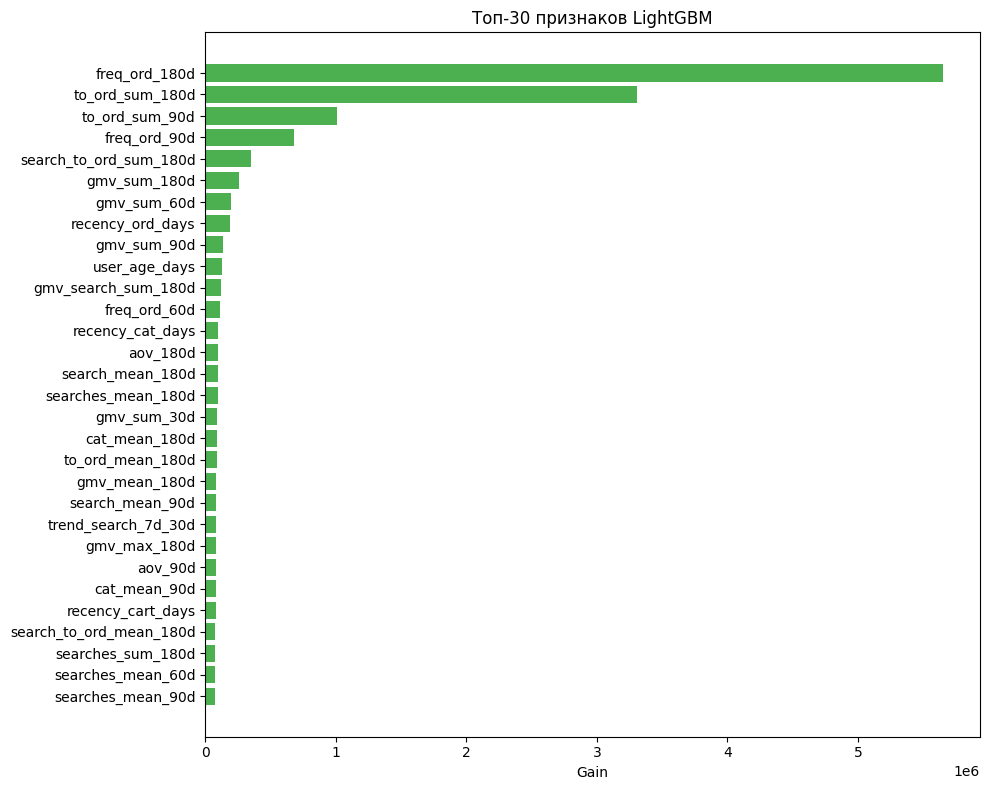

In [5]:
imp = trained_models[-1].feature_importance(importance_type='gain')
sorted_imp = sorted(zip(features, imp), key=lambda x: -x[1])

fig, ax = plt.subplots(figsize=(10, 8))
top_n = 30
top_feats = sorted_imp[:top_n]
ax.barh([f[0] for f in reversed(top_feats)], [f[1] for f in reversed(top_feats)], color='#4CAF50')
ax.set_xlabel('Gain')
ax.set_title(f'Топ-{top_n} признаков LightGBM')
plt.tight_layout()
plt.show()